In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')

In [2]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.shape

(244, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

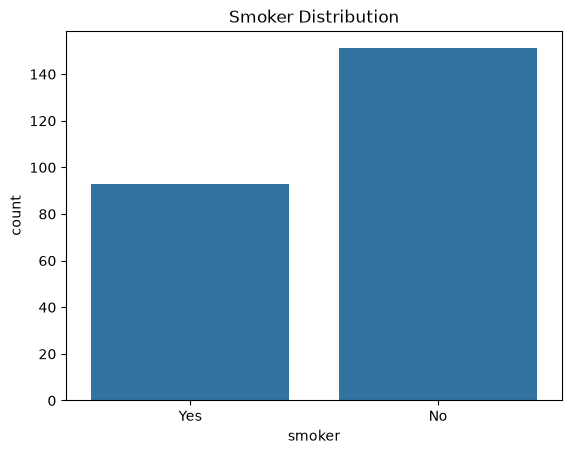

In [ ]:

sns.countplot(x='smoker', data=df)
plt.title('Smoker Distribution')
plt.show()

In [10]:
df.isnull().sum()


total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1)

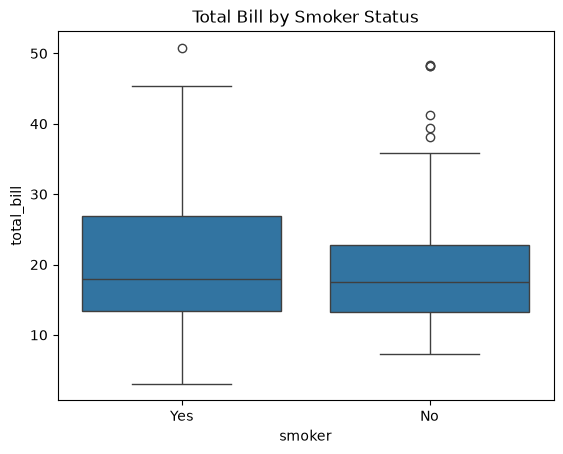

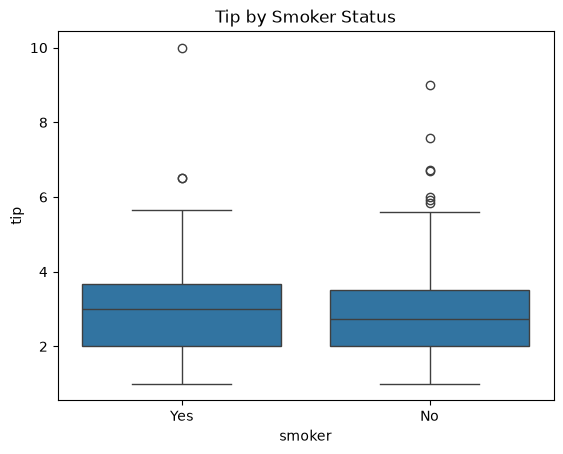

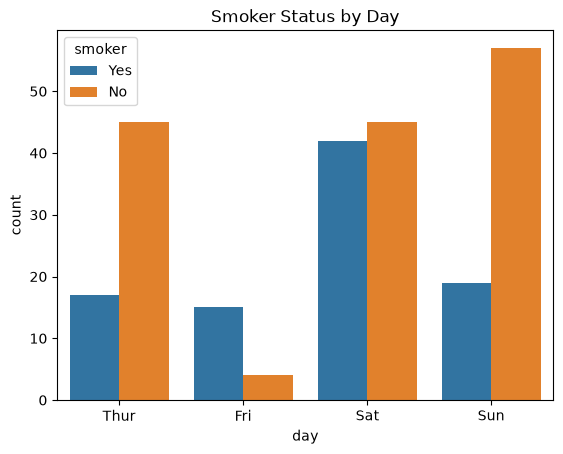

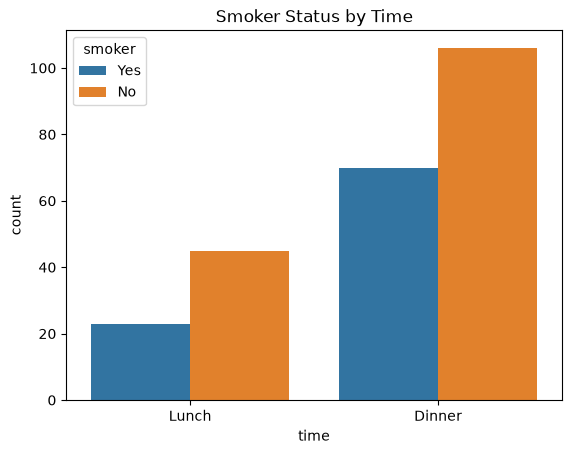

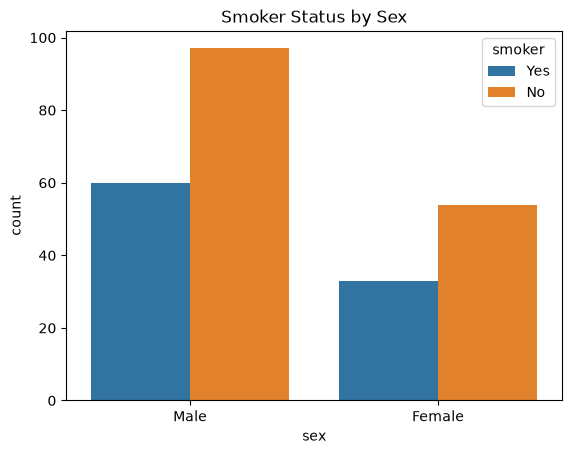

In [12]:
sns.boxplot(x='smoker', y='total_bill', data=df)
plt.title('Total Bill by Smoker Status')
plt.show()

sns.boxplot(x='smoker', y='tip', data=df)
plt.title('Tip by Smoker Status')
plt.show()

sns.countplot(x='day', hue='smoker', data=df)
plt.title('Smoker Status by Day')
plt.show()

sns.countplot(x='time', hue='smoker', data=df)
plt.title('Smoker Status by Time')
plt.show()

sns.countplot(x='sex', hue='smoker', data=df)
plt.title('Smoker Status by Sex')
plt.show()

In [14]:
#Encoding categorical varaibles
df_encoded = df.copy()
# Binary columns - simple mapping
df_encoded['sex'] = df_encoded['sex'].map({'Male': 0, 'Female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'No': 0, 'Yes': 1})
df_encoded['time'] = df_encoded['time'].map({'Lunch': 0, 'Dinner': 1})

# Multi-category column - one-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=['day'], drop_first=True)

df_encoded.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,0,1,2,False,False,True
1,10.34,1.66,0,0,1,3,False,False,True
2,21.01,3.50,0,0,1,3,False,False,True
3,23.68,3.31,0,0,1,2,False,False,True
4,24.59,3.61,1,0,1,4,False,False,True


In [15]:
X = df_encoded.drop(columns=['smoker'])

In [16]:
y = df_encoded['smoker']

In [17]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

print(X_train.shape, X_test.shape)

(170, 8) (74, 8)


In [18]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[105., 65.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.62,0.38]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,7.599e-08
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['total_bill','tip','sex',...,'day_Fri','day_Sat','day_Sun']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[18.62, 2.84, 0.38,..., 0.01, 0.24, 0.42], [20.71, 3. , 0.37,..., 0.15, 0.38, 0.28]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[64.16, 1.4 , 0.24,..., 0.01, 0.18, 0.24], [92.39, 1.64, 0.23,..., 0.13, 0.24, 0.2 ]]"


In [19]:
#predict
y_pred = gnb.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[39  7]
 [22  6]]
Accuracy: 0.6081081081081081
              precision    recall  f1-score   support

           0       0.64      0.85      0.73        46
           1       0.46      0.21      0.29        28

    accuracy                           0.61        74
   macro avg       0.55      0.53      0.51        74
weighted avg       0.57      0.61      0.56        74



In [21]:
majority_class_accuracy = max(y_test.value_counts(normalize=True))
print("Majority class baseline accuracy:", majority_class_accuracy)
print("GaussianNB accuracy:", accuracy_score(y_test, y_pred))

Majority class baseline accuracy: 0.6216216216216216
GaussianNB accuracy: 0.6081081081081081
